
# NB-03 · Momentum Contrast (MoCo) + DeepLabV3-ResNet50  
## Brain Tumour MRI Binary Semantic Segmentation from COCO Polygons

**Course:** CSE 438: Digital Image Processing  
**Course Instructor:** Dr Md Rifat Ahmmad Rashid  
**Department:** Department of Computer Science and Engineering  
**Institution:** East West University (EWU)

---

### Learning objective

This notebook examines whether a representation learned without tumour labels can strengthen a supervised segmentation model. The workflow has two consecutive stages:

1. **MoCo pretraining:** a ResNet-50 query encoder learns MRI representations by matching two augmented views of the same image against a queue of negative examples.
2. **DeepLabV3 fine-tuning:** the trained query encoder is transferred directly into the ResNet-50 backbone of DeepLabV3; polygon annotations are rasterised and merged into binary tumour masks.

### Dataset convention

The source dataset stores segmentation boundaries as COCO polygons. All polygons associated with one MRI are merged into one semantic mask:

\[
0=\text{background}, \qquad 1=\text{tumour region}.
\]

### Computational safety note

This notebook uses standard contiguous tensors only. A CUDA kernel probe is executed before model training. Automatic mixed precision (AMP) is enabled only if the probe succeeds; otherwise, all stages run on CPU with a diagnostic message.



## Method overview

### Momentum Contrast

For one augmented MRI view, the **query encoder** produces a normalised embedding \(\mathbf{q}\). A momentum-updated **key encoder** produces the positive embedding \(\mathbf{k}_{+}\) from a second view. A first-in-first-out queue stores previous key embeddings as negatives. The contrastive task rewards agreement between paired views while discouraging similarity to queued negatives.

\[
\mathcal{L}_{\mathrm{MoCo}} =
-\log
\frac{\exp(\mathbf{q}^{\top}\mathbf{k}_{+}/\tau)}
{\exp(\mathbf{q}^{\top}\mathbf{k}_{+}/\tau)+
\sum_{i=1}^{K}\exp(\mathbf{q}^{\top}\mathbf{k}_{i}/\tau)}
\]

where \(K\) is queue size, \(\tau\) is temperature, and the key encoder is updated by

\[
\theta_k \leftarrow m\theta_k+(1-m)\theta_q.
\]

### Direct transfer to segmentation

The trained **MoCo query ResNet-50 encoder** and the **DeepLabV3 ResNet-50 backbone** share compatible convolutional parameters. The transfer is therefore architectural, not approximate: matching encoder tensors are copied into DeepLabV3 before segmentation fine-tuning.

### Numerical stability

Encoder forward passes may use AMP on a functional CUDA device. Contrastive similarity logits and cross-entropy are explicitly computed in `float32`, avoiding reduced-precision instability in the queue-based objective.



### Revision note

This corrected version updates the MoCo training implementation so that the negative-key queue is modified only after gradient computation for the current mini-batch. The smoke test now executes both forward and backward propagation. The qualitative overlay uses explicit error-coded colours so that a ground-truth tumour region remains visible even when no foreground is predicted.


In [1]:

# ============================================================
# 1. Imports, configuration, output folders, and reproducibility
# ============================================================

from pathlib import Path
from contextlib import nullcontext
import copy
import json
import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle
from PIL import Image, ImageDraw

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms as T
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.models.segmentation import deeplabv3_resnet50

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)

# ------------------------------------------------------------
# Dataset path required for this CSE 438 notebook.
# ------------------------------------------------------------
DATA_ROOT = Path("/kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation")

# All generated artefacts are retained in the Kaggle working directory.
OUTPUT_DIR = Path("/kaggle/working/moco_deeplabv3_brain_tumour")
FIGURE_DIR = OUTPUT_DIR / "figures"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
METRIC_DIR = OUTPUT_DIR / "metrics"
for directory in [OUTPUT_DIR, FIGURE_DIR, CHECKPOINT_DIR, METRIC_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Core experiment configuration.
# ------------------------------------------------------------
SEED = 438
IMAGE_SIZE = 224
NUM_CLASSES = 2                       # background and tumour
MOCO_EPOCHS = 10
SEGMENTATION_EPOCHS = 10
QUEUE_SIZE = 2048                     # number of negative keys retained in memory
EMBEDDING_DIM = 128
MOMENTUM = 0.999
TEMPERATURE = 0.20
MOCO_LR = 3e-4
SEGMENTATION_LR = 2e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2

# For a pure self-supervised classroom experiment, keep this False.
# Setting it True adds ImageNet supervised initialisation before MoCo.
USE_IMAGENET_INITIALISATION = False

def seed_everything(seed: int = SEED) -> None:
    """Provide repeatable splitting, augmentation choices, and weight initialisation."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        try:
            torch.cuda.manual_seed_all(seed)
        except Exception:
            pass

seed_everything()

print(f"Torch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Output directory: {OUTPUT_DIR}")


Torch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
Output directory: /kaggle/working/moco_deeplabv3_brain_tumour


In [2]:

# ============================================================
# 2. CUDA compatibility probe and conditional AMP activation
# ============================================================

def choose_safe_device():
    """
    Kaggle occasionally exposes a GPU for which the installed Torch build
    cannot execute CUDA kernels. A successful availability check alone is
    therefore insufficient. This function performs an actual convolution,
    reduction, and backward pass before enabling CUDA or AMP.
    """
    if not torch.cuda.is_available():
        print("CUDA is not reported as available. Training will run on CPU; AMP is disabled.")
        return torch.device("cpu"), False

    try:
        probe_input = torch.randn(2, 3, 24, 24, device="cuda", requires_grad=True)
        probe_layer = nn.Conv2d(3, 4, kernel_size=3, padding=1).to("cuda")
        probe_output = probe_layer(probe_input).square().mean()
        probe_output.backward()
        torch.cuda.synchronize()
        device_name = torch.cuda.get_device_name(0)
        print(f"CUDA kernel probe succeeded on: {device_name}")
        print("AMP is enabled for compatible CUDA forward passes.")
        return torch.device("cuda"), True
    except Exception as error:
        print("CUDA was detected, but a CUDA kernel test failed.")
        print(f"Diagnostic: {type(error).__name__}: {error}")
        print("Safe fallback selected: CPU training with AMP disabled.")
        return torch.device("cpu"), False

DEVICE, AMP_ENABLED = choose_safe_device()

def autocast_context():
    """Use float16 autocasting only after the CUDA execution probe succeeded."""
    if not AMP_ENABLED:
        return nullcontext()
    try:
        return torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=True)
    except AttributeError:
        return torch.cuda.amp.autocast(dtype=torch.float16, enabled=True)

def contrastive_float32_context(tensor):
    """Disable AMP locally while MoCo logits and cross-entropy are calculated."""
    if not tensor.is_cuda:
        return nullcontext()
    try:
        return torch.amp.autocast(device_type="cuda", enabled=False)
    except AttributeError:
        return torch.cuda.amp.autocast(enabled=False)

def make_grad_scaler():
    """Create a GradScaler while retaining compatibility with common Kaggle Torch builds."""
    try:
        return torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

# CPU execution is kept feasible for validation of notebook logic.
MOCO_BATCH_SIZE = 32 if DEVICE.type == "cuda" else 4
SEGMENTATION_BATCH_SIZE = 6 if DEVICE.type == "cuda" else 2
PIN_MEMORY = DEVICE.type == "cuda"

print(f"Selected device: {DEVICE}")
print(f"MoCo batch size: {MOCO_BATCH_SIZE}; segmentation batch size: {SEGMENTATION_BATCH_SIZE}")


CUDA kernel probe succeeded on: Tesla T4
AMP is enabled for compatible CUDA forward passes.
Selected device: cuda
MoCo batch size: 32; segmentation batch size: 6



## COCO polygons to binary semantic masks

COCO stores one or more polygon segments for each annotated object. Semantic segmentation does not preserve tumour instance identity in this experiment. Consequently, each valid polygon is filled with class value `1`, and overlapping or multiple tumour polygons are merged into the same foreground mask.


In [3]:

# ============================================================
# 3. COCO polygon parsing and paired segmentation transformations
# ============================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
NORMALISE = T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

def read_coco_records(split_dir: Path):
    """Load image records and annotation lists indexed by COCO image id."""
    annotation_file = split_dir / "_annotations.coco.json"
    if not annotation_file.exists():
        raise FileNotFoundError(f"COCO annotation file was not found: {annotation_file}")

    with open(annotation_file, "r", encoding="utf-8") as file:
        coco = json.load(file)

    annotations_by_image = {}
    for annotation in coco.get("annotations", []):
        annotations_by_image.setdefault(annotation["image_id"], []).append(annotation)

    records = []
    for image_info in coco.get("images", []):
        image_path = split_dir / image_info["file_name"]
        if not image_path.exists():
            # Roboflow exports sometimes include a nested relative filename;
            # use the basename as a cautious fallback.
            candidate = split_dir / Path(image_info["file_name"]).name
            image_path = candidate if candidate.exists() else image_path

        if image_path.exists():
            records.append(
                {
                    "id": image_info["id"],
                    "file_name": image_info["file_name"],
                    "image_path": image_path,
                    "annotations": annotations_by_image.get(image_info["id"], []),
                }
            )

    if len(records) == 0:
        raise RuntimeError(f"No readable images were indexed from {split_dir}.")
    return records

def polygons_to_binary_mask(image_size, annotations):
    """
    Rasterise all polygon annotations for one MRI into one class-index mask.
    Output pixel values are strictly 0 (background) or 1 (tumour).
    """
    mask = Image.new("L", image_size, 0)
    drawer = ImageDraw.Draw(mask)

    for annotation in annotations:
        segmentation = annotation.get("segmentation", [])
        if not isinstance(segmentation, list):
            raise ValueError(
                "This notebook expects COCO polygon segmentations; an RLE annotation was encountered."
            )

        for polygon in segmentation:
            if len(polygon) < 6:
                continue
            xy_points = [(float(polygon[i]), float(polygon[i + 1]))
                         for i in range(0, len(polygon) - 1, 2)]
            drawer.polygon(xy_points, outline=1, fill=1)

    return mask

class PairedSegmentationTransform:
    """
    Apply spatial changes identically to an MRI and its ground-truth mask.
    Bilinear interpolation is used for MRI intensity values; nearest-neighbour
    interpolation protects the discrete class labels of the binary mask.
    """
    def __init__(self, size=IMAGE_SIZE, training=False):
        self.size = size
        self.training = training

    def __call__(self, image, mask):
        if self.training:
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)
            if random.random() < 0.25:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

            angle = random.uniform(-10.0, 10.0)
            image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR, fill=0)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST, fill=0)

        image = TF.resize(image, [self.size, self.size], interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, [self.size, self.size], interpolation=InterpolationMode.NEAREST)

        image_tensor = NORMALISE(TF.to_tensor(image)).contiguous()
        mask_tensor = torch.from_numpy(np.asarray(mask, dtype=np.int64)).contiguous()
        mask_tensor = (mask_tensor > 0).long()
        return image_tensor, mask_tensor

class COCOSemanticMaskDataset(Dataset):
    """Supervised dataset returning a normalised MRI, merged binary mask, and file name."""
    def __init__(self, split_dir, size=IMAGE_SIZE, training=False):
        self.split_dir = Path(split_dir)
        self.records = read_coco_records(self.split_dir)
        self.transform = PairedSegmentationTransform(size=size, training=training)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        record = self.records[index]
        image = Image.open(record["image_path"]).convert("RGB")
        mask = polygons_to_binary_mask(image.size, record["annotations"])
        image_tensor, mask_tensor = self.transform(image, mask)
        return image_tensor, mask_tensor, record["file_name"]

# MoCo needs two independently augmented views, but does not use labels.
MOCO_AUGMENTATION = T.Compose(
    [
        T.RandomResizedCrop(IMAGE_SIZE, scale=(0.55, 1.0), interpolation=InterpolationMode.BILINEAR),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomApply([T.ColorJitter(brightness=0.25, contrast=0.25)], p=0.7),
        T.RandomGrayscale(p=0.15),
        T.RandomApply([T.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5))], p=0.35),
        T.ToTensor(),
        NORMALISE,
    ]
)

class MoCOTwoViewDataset(Dataset):
    """Use each unlabelled training MRI to produce two correlated contrastive views."""
    def __init__(self, split_dir):
        self.records = read_coco_records(Path(split_dir))

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        image = Image.open(self.records[index]["image_path"]).convert("RGB")
        query_view = MOCO_AUGMENTATION(image).contiguous()
        key_view = MOCO_AUGMENTATION(image).contiguous()
        return query_view, key_view


In [4]:

# ============================================================
# 4. Dataset construction, loaders, and mask distribution
# ============================================================

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset root not found: {DATA_ROOT}\n"
        "Add the Kaggle dataset to the notebook and confirm the required dataset path."
    )

TRAIN_DIR = DATA_ROOT / "train"
VALID_DIR = DATA_ROOT / "valid"
TEST_DIR = DATA_ROOT / "test"

train_dataset = COCOSemanticMaskDataset(TRAIN_DIR, training=True)
train_eval_dataset = COCOSemanticMaskDataset(TRAIN_DIR, training=False)
valid_dataset = COCOSemanticMaskDataset(VALID_DIR, training=False)
test_dataset = COCOSemanticMaskDataset(TEST_DIR, training=False)
moco_dataset = MoCOTwoViewDataset(TRAIN_DIR)

loader_arguments = dict(
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

train_loader = DataLoader(
    train_dataset, batch_size=SEGMENTATION_BATCH_SIZE, shuffle=True,
    drop_last=False, **loader_arguments
)
valid_loader = DataLoader(
    valid_dataset, batch_size=SEGMENTATION_BATCH_SIZE, shuffle=False,
    drop_last=False, **loader_arguments
)
test_loader = DataLoader(
    test_dataset, batch_size=SEGMENTATION_BATCH_SIZE, shuffle=False,
    drop_last=False, **loader_arguments
)
feature_loader = DataLoader(
    valid_dataset, batch_size=SEGMENTATION_BATCH_SIZE, shuffle=False,
    drop_last=False, **loader_arguments
)

# drop_last=True stabilises batch construction and queue updates during contrastive training.
moco_loader = DataLoader(
    moco_dataset, batch_size=MOCO_BATCH_SIZE, shuffle=True,
    drop_last=True, **loader_arguments
)

print(f"Training MRIs:   {len(train_dataset)}")
print(f"Validation MRIs: {len(valid_dataset)}")
print(f"Test MRIs:       {len(test_dataset)}")
print(f"MoCo batches per epoch: {len(moco_loader)}")

def summarise_foreground(dataset, split_name):
    foreground_pixels = []
    positive_images = 0
    for _, mask, _ in tqdm(dataset, desc=f"Measuring masks: {split_name}", leave=False):
        count = int(mask.sum().item())
        foreground_pixels.append(count)
        positive_images += int(count > 0)

    total_pixels = len(dataset) * IMAGE_SIZE * IMAGE_SIZE
    return {
        "split": split_name,
        "images": len(dataset),
        "images_with_tumour": positive_images,
        "tumour_image_percentage": 100.0 * positive_images / max(len(dataset), 1),
        "foreground_pixel_percentage": 100.0 * sum(foreground_pixels) / max(total_pixels, 1),
    }

mask_summary = pd.DataFrame(
    [
        summarise_foreground(train_eval_dataset, "train"),
        summarise_foreground(valid_dataset, "valid"),
        summarise_foreground(test_dataset, "test"),
    ]
)
mask_summary.to_csv(METRIC_DIR / "mask_distribution.csv", index=False)
mask_summary


Training MRIs:   1502
Validation MRIs: 429
Test MRIs:       215
MoCo batches per epoch: 46


Measuring masks: train:   0%|          | 0/1502 [00:00<?, ?it/s]

Measuring masks: valid:   0%|          | 0/429 [00:00<?, ?it/s]

Measuring masks: test:   0%|          | 0/215 [00:00<?, ?it/s]

,split,images,images_with_tumour,tumour_image_percentage,foreground_pixel_percentage
0,train,1502,1501,99.933422,3.710254
1,valid,429,429,100.000000,3.721827
2,test,215,215,100.000000,3.716379


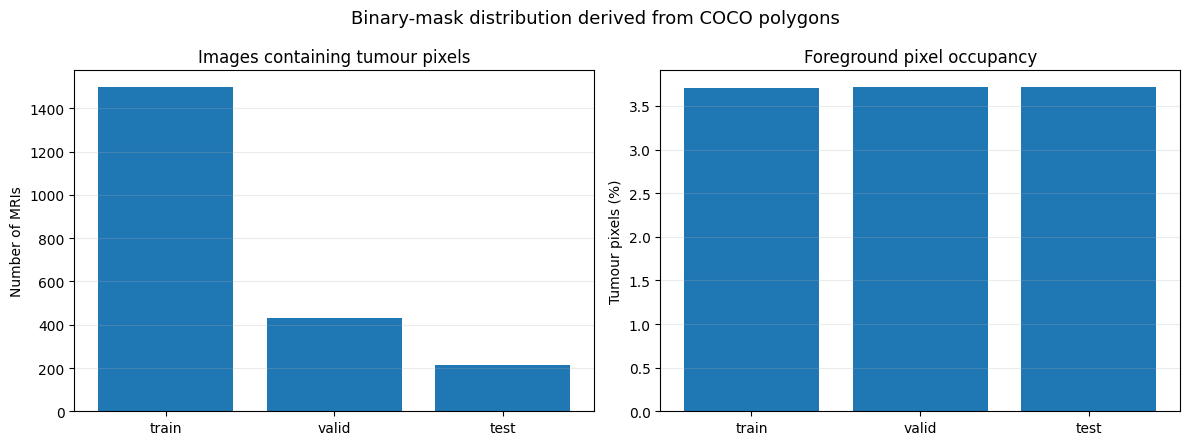

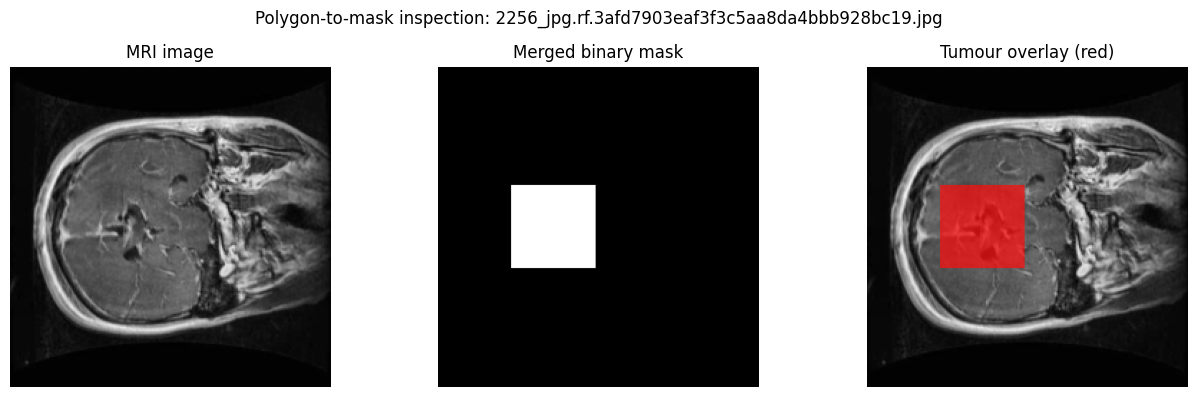

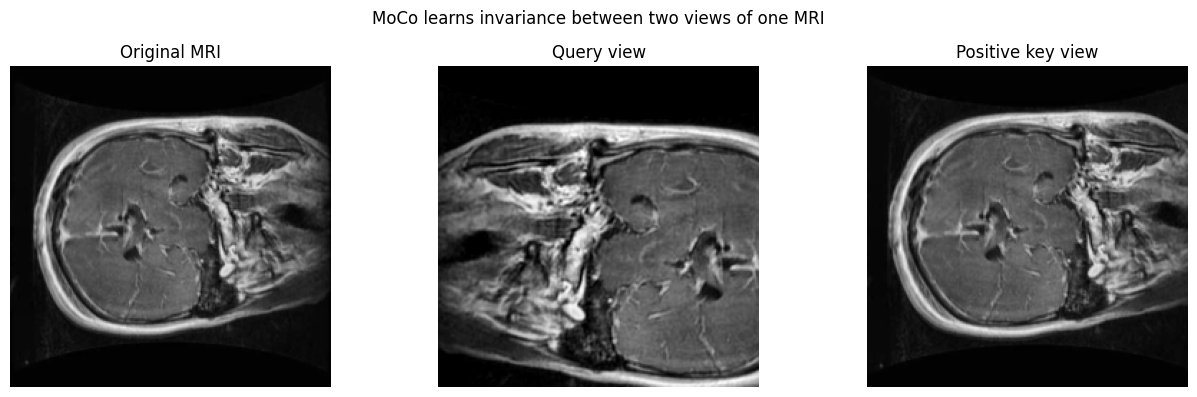

In [5]:

# ============================================================
# 5. COCO-mask visualisation and MoCo paired views
# ============================================================

def undo_normalisation(tensor):
    """Recover a displayable RGB image from a normalised model tensor."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor.detach().cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

def make_mask_overlay(image_array, mask_array, colour=(1.0, 0.05, 0.05), alpha=0.72):
    """
    Blend a strongly visible colour only inside the selected binary mask.
    The function avoids a weak red-channel adjustment, which can be difficult
    to see on grayscale MRIs with small tumour regions.
    """
    overlay = image_array.copy()
    region = np.asarray(mask_array).astype(bool)
    if region.any():
        colour_array = np.asarray(colour, dtype=np.float32)
        overlay[region] = (1.0 - alpha) * overlay[region] + alpha * colour_array
    return np.clip(overlay, 0.0, 1.0)

# ----- Visualise pixel and image-level foreground statistics.
figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(mask_summary["split"], mask_summary["images_with_tumour"])
axes[0].set_title("Images containing tumour pixels")
axes[0].set_ylabel("Number of MRIs")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(mask_summary["split"], mask_summary["foreground_pixel_percentage"])
axes[1].set_title("Foreground pixel occupancy")
axes[1].set_ylabel("Tumour pixels (%)")
axes[1].grid(axis="y", alpha=0.25)

figure.suptitle("Binary-mask distribution derived from COCO polygons", fontsize=13)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "01_mask_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

# ----- Select a positive training example to verify polygon rasterisation.
positive_index = next(
    (i for i in range(len(train_eval_dataset)) if train_eval_dataset[i][1].sum() > 0), 0
)
sample_image, sample_mask, sample_name = train_eval_dataset[positive_index]
display_image = undo_normalisation(sample_image)
mask_array = sample_mask.numpy()
ground_truth_overlay = make_mask_overlay(display_image, mask_array)

figure, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(display_image)
axes[0].set_title("MRI image")
axes[1].imshow(mask_array, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Merged binary mask")
axes[2].imshow(ground_truth_overlay)
axes[2].set_title("Tumour overlay (red)")
for axis in axes:
    axis.axis("off")
figure.suptitle(f"Polygon-to-mask inspection: {sample_name}", fontsize=12)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "02_polygon_mask_overlay.png", dpi=180, bbox_inches="tight")
plt.show()

# ----- Two MoCo augmentations from the same source MRI.
view_q, view_k = moco_dataset[positive_index]
figure, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(display_image)
axes[0].set_title("Original MRI")
axes[1].imshow(undo_normalisation(view_q))
axes[1].set_title("Query view")
axes[2].imshow(undo_normalisation(view_k))
axes[2].set_title("Positive key view")
for axis in axes:
    axis.axis("off")
figure.suptitle("MoCo learns invariance between two views of one MRI", fontsize=12)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "03_moco_two_views.png", dpi=180, bbox_inches="tight")
plt.show()


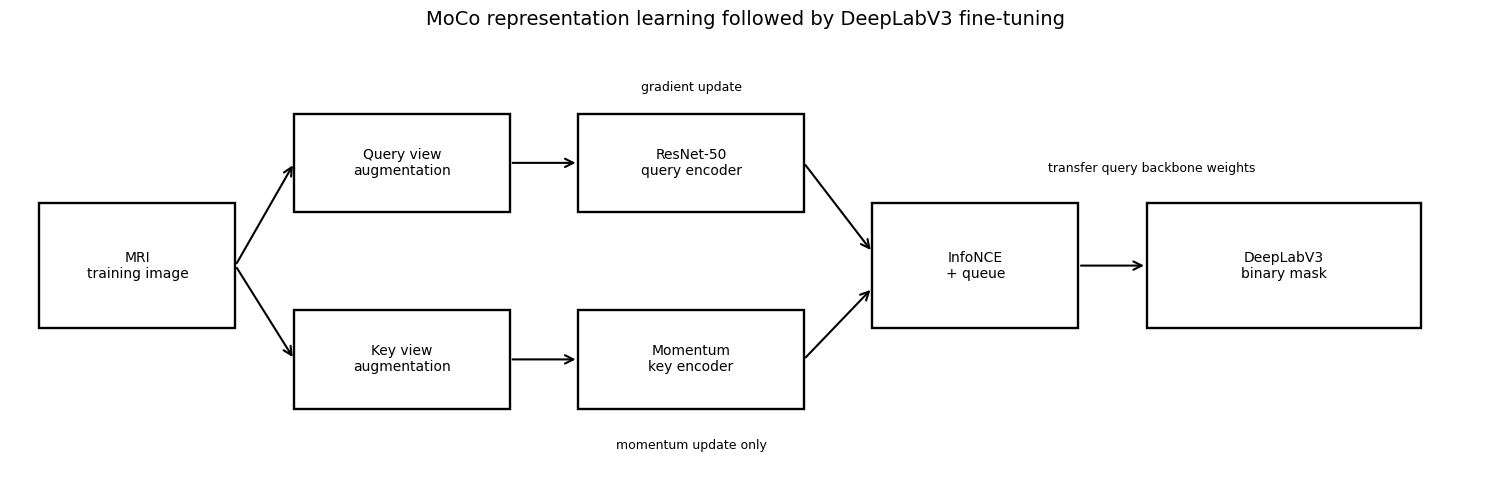

In [6]:

# ============================================================
# 6. Instructional workflow diagram: MoCo pretraining to DeepLabV3
# ============================================================

figure, axis = plt.subplots(figsize=(15, 5))
axis.set_xlim(0, 15)
axis.set_ylim(0, 5)
axis.axis("off")

boxes = [
    (0.3, 1.7, 2.0, 1.4, "MRI\ntraining image"),
    (2.9, 3.0, 2.2, 1.1, "Query view\naugmentation"),
    (2.9, 0.8, 2.2, 1.1, "Key view\naugmentation"),
    (5.8, 3.0, 2.3, 1.1, "ResNet-50\nquery encoder"),
    (5.8, 0.8, 2.3, 1.1, "Momentum\nkey encoder"),
    (8.8, 1.7, 2.1, 1.4, "InfoNCE\n+ queue"),
    (11.6, 1.7, 2.8, 1.4, "DeepLabV3\nbinary mask"),
]

for x, y, width, height, label in boxes:
    axis.add_patch(Rectangle((x, y), width, height, fill=False, linewidth=1.7))
    axis.text(x + width / 2, y + height / 2, label, ha="center", va="center", fontsize=10)

arrows = [
    ((2.3, 2.4), (2.9, 3.55)),
    ((2.3, 2.4), (2.9, 1.35)),
    ((5.1, 3.55), (5.8, 3.55)),
    ((5.1, 1.35), (5.8, 1.35)),
    ((8.1, 3.55), (8.8, 2.55)),
    ((8.1, 1.35), (8.8, 2.15)),
    ((10.9, 2.4), (11.6, 2.4)),
]

for start, end in arrows:
    axis.add_patch(FancyArrowPatch(start, end, arrowstyle="->", mutation_scale=15, linewidth=1.5))

axis.text(6.95, 4.35, "gradient update", ha="center", fontsize=9)
axis.text(6.95, 0.35, "momentum update only", ha="center", fontsize=9)
axis.text(11.65, 3.45, "transfer query backbone weights", ha="center", fontsize=9)

axis.set_title("MoCo representation learning followed by DeepLabV3 fine-tuning", fontsize=14)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "04_workflow_diagram.png", dpi=180, bbox_inches="tight")
plt.show()



## MoCo implementation

The queue allows many negative keys without requiring a very large GPU batch. The key encoder is not optimised by back-propagation; it follows the query encoder through a high-momentum exponential moving average. In the implementation below, the encoder and projection-head forward passes may run under AMP, while similarity calculation and the InfoNCE loss remain in `float32`.


In [7]:

# ============================================================
# 7. ResNet-50 encoder and AMP-stable MoCo model
# ============================================================

def build_resnet_encoder(use_imagenet=False):
    """
    Create the ResNet-50 representation encoder. The classification head is
    removed so that the 2048-dimensional pooled representation can feed the
    MoCo projection head and later transfer to DeepLabV3.
    """
    weights = None
    if use_imagenet:
        try:
            weights = ResNet50_Weights.DEFAULT
            encoder = resnet50(weights=weights)
            print("ResNet-50 initialised with ImageNet weights.")
        except Exception as error:
            print(f"ImageNet initialisation was unavailable ({error}); random initialisation is used.")
            encoder = resnet50(weights=None)
    else:
        encoder = resnet50(weights=None)

    encoder.fc = nn.Identity()
    return encoder

class MoCo(nn.Module):
    """
    Momentum Contrast with:
      - a trainable query encoder and query projection head;
      - momentum-updated key counterparts;
      - a FIFO queue of normalised negative key representations.

    The queue is read during forward propagation and updated only after
    backward propagation has completed. This ordering is essential because
    the stored negatives are required to calculate gradients for query vectors.
    """
    def __init__(
        self,
        dim=EMBEDDING_DIM,
        queue_size=QUEUE_SIZE,
        momentum=MOMENTUM,
        temperature=TEMPERATURE,
        use_imagenet=False,
    ):
        super().__init__()
        self.K = queue_size
        self.m = momentum
        self.T = temperature

        self.encoder_q = build_resnet_encoder(use_imagenet)
        self.encoder_k = build_resnet_encoder(use_imagenet)

        self.projector_q = nn.Sequential(
            nn.Linear(2048, 2048),
            nn.ReLU(inplace=True),
            nn.Linear(2048, dim),
        )
        self.projector_k = nn.Sequential(
            nn.Linear(2048, 2048),
            nn.ReLU(inplace=True),
            nn.Linear(2048, dim),
        )

        # Initialise key parameters from query parameters and disable gradients.
        self.encoder_k.load_state_dict(self.encoder_q.state_dict())
        self.projector_k.load_state_dict(self.projector_q.state_dict())
        for parameter in list(self.encoder_k.parameters()) + list(self.projector_k.parameters()):
            parameter.requires_grad = False

        # A float32 normalised negative queue protects contrastive arithmetic.
        initial_queue = F.normalize(torch.randn(dim, queue_size, dtype=torch.float32), dim=0)
        self.register_buffer("queue", initial_queue)
        self.register_buffer("queue_ptr", torch.zeros(1, dtype=torch.long))

    @torch.no_grad()
    def momentum_update_key_encoder(self):
        for query_parameter, key_parameter in zip(self.encoder_q.parameters(), self.encoder_k.parameters()):
            key_parameter.data.mul_(self.m).add_(query_parameter.data, alpha=1.0 - self.m)
        for query_parameter, key_parameter in zip(self.projector_q.parameters(), self.projector_k.parameters()):
            key_parameter.data.mul_(self.m).add_(query_parameter.data, alpha=1.0 - self.m)

    @torch.no_grad()
    def dequeue_and_enqueue(self, keys):
        """
        Add keys only after loss.backward() has completed. During forward, the
        current queue participates in the gradient calculation for q; updating
        it earlier causes an autograd version-counter failure.
        """
        keys = keys.detach().float()
        batch_size = keys.shape[0]

        if batch_size >= self.K:
            self.queue.copy_(keys[-self.K:].T)
            self.queue_ptr.zero_()
            return

        pointer = int(self.queue_ptr.item())
        end_pointer = pointer + batch_size

        if end_pointer <= self.K:
            self.queue[:, pointer:end_pointer] = keys.T
        else:
            first_length = self.K - pointer
            self.queue[:, pointer:] = keys[:first_length].T
            self.queue[:, :batch_size - first_length] = keys[first_length:].T

        self.queue_ptr[0] = (pointer + batch_size) % self.K

    def forward(self, query_image, key_image):
        # Representation networks are allowed to benefit from AMP when enabled.
        q = F.normalize(self.projector_q(self.encoder_q(query_image)), dim=1)

        with torch.no_grad():
            self.momentum_update_key_encoder()
            k = F.normalize(self.projector_k(self.encoder_k(key_image)), dim=1)

        # Disable autocasting for the contrastive objective. The similarities,
        # temperature scaling, and cross-entropy loss remain in float32.
        with contrastive_float32_context(q):
            q32 = q.float()
            k32 = k.float()

            # Clone creates an independent queue snapshot for the current graph.
            # It prevents any later queue update from altering saved backward data.
            queue_snapshot = self.queue.detach().clone().float()

            positive_logits = torch.einsum("nc,nc->n", q32, k32).unsqueeze(1)
            negative_logits = torch.einsum("nc,ck->nk", q32, queue_snapshot)
            logits = torch.cat([positive_logits, negative_logits], dim=1) / self.T
            labels = torch.zeros(logits.size(0), dtype=torch.long, device=logits.device)
            loss = F.cross_entropy(logits, labels)

        # Key embeddings are returned to the training loop. They are enqueued
        # after backward and optimiser update, not during this forward pass.
        return (
            loss,
            logits.detach(),
            positive_logits.detach(),
            negative_logits.detach(),
            k32.detach(),
        )


In [8]:

# ============================================================
# 8. MoCo backward smoke test, ten-epoch self-supervised pretraining, and checkpointing
# ============================================================

if len(moco_loader) == 0:
    raise RuntimeError(
        "MoCo DataLoader has zero batches. Reduce MOCO_BATCH_SIZE because drop_last=True is required."
    )

# ----- Forward-and-backward smoke test before full pretraining.
# The backward step is necessary because queue-related autograd failures do not
# appear during a forward-only numerical test.
smoke_model = MoCo(
    dim=EMBEDDING_DIM,
    queue_size=min(QUEUE_SIZE, 256),
    momentum=MOMENTUM,
    temperature=TEMPERATURE,
    use_imagenet=USE_IMAGENET_INITIALISATION,
).to(DEVICE)

smoke_optimizer = torch.optim.AdamW(
    list(smoke_model.encoder_q.parameters()) + list(smoke_model.projector_q.parameters()),
    lr=MOCO_LR,
    weight_decay=WEIGHT_DECAY,
)
smoke_scaler = make_grad_scaler()

smoke_query, smoke_key = next(iter(moco_loader))
smoke_query = smoke_query.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
smoke_key = smoke_key.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()

smoke_optimizer.zero_grad(set_to_none=True)
with autocast_context():
    smoke_loss, smoke_logits, _, _, smoke_keys_to_enqueue = smoke_model(smoke_query, smoke_key)

assert smoke_loss.dtype == torch.float32, "MoCo loss must be float32 for AMP stability."
assert torch.isfinite(smoke_loss), "MoCo smoke-test loss is not finite."
assert smoke_logits.shape[1] == min(QUEUE_SIZE, 256) + 1

smoke_scaler.scale(smoke_loss).backward()
smoke_scaler.step(smoke_optimizer)
smoke_scaler.update()
smoke_model.dequeue_and_enqueue(smoke_keys_to_enqueue)

print(f"MoCo forward/backward smoke test passed. Float32 InfoNCE loss: {smoke_loss.item():.4f}")

del smoke_model, smoke_optimizer, smoke_scaler, smoke_query, smoke_key, smoke_keys_to_enqueue
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

# ----- Actual model; preserve its initial state for later feature-space comparison.
moco_model = MoCo(
    dim=EMBEDDING_DIM,
    queue_size=QUEUE_SIZE,
    momentum=MOMENTUM,
    temperature=TEMPERATURE,
    use_imagenet=USE_IMAGENET_INITIALISATION,
).to(DEVICE)

initial_encoder_state = copy.deepcopy(moco_model.encoder_q.state_dict())
torch.save(initial_encoder_state, CHECKPOINT_DIR / "resnet50_initial_encoder_state.pth")

moco_optimizer = torch.optim.AdamW(
    list(moco_model.encoder_q.parameters()) + list(moco_model.projector_q.parameters()),
    lr=MOCO_LR,
    weight_decay=WEIGHT_DECAY,
)
moco_scaler = make_grad_scaler()

moco_history = []
final_positive_similarities = None
final_negative_similarities = None

for epoch in range(1, MOCO_EPOCHS + 1):
    moco_model.train()
    epoch_losses = []
    epoch_positive = []
    epoch_negative = []

    progress = tqdm(moco_loader, desc=f"MoCo epoch {epoch:02d}/{MOCO_EPOCHS}", leave=True)
    for query_view, key_view in progress:
        query_view = query_view.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        key_view = key_view.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()

        moco_optimizer.zero_grad(set_to_none=True)
        with autocast_context():
            (
                loss,
                _,
                positive_similarity,
                negative_similarity,
                keys_to_enqueue,
            ) = moco_model(query_view, key_view)

        # Backward propagation uses the unchanged queue snapshot created during
        # the forward pass. The live queue is updated only after this step.
        moco_scaler.scale(loss).backward()
        moco_scaler.step(moco_optimizer)
        moco_scaler.update()
        moco_model.dequeue_and_enqueue(keys_to_enqueue)

        epoch_losses.append(loss.item())
        epoch_positive.extend(positive_similarity.float().cpu().numpy().ravel().tolist())

        # Sample negatives for a readable distribution plot rather than storing
        # every queue similarity from every batch.
        sampled_negatives = negative_similarity[:, : min(128, negative_similarity.shape[1])]
        epoch_negative.extend(sampled_negatives.float().cpu().numpy().ravel().tolist())

        progress.set_postfix(loss=f"{np.mean(epoch_losses):.4f}")

    epoch_record = {
        "epoch": epoch,
        "moco_loss": float(np.mean(epoch_losses)),
        "positive_similarity": float(np.mean(epoch_positive)),
        "negative_similarity": float(np.mean(epoch_negative)),
    }
    moco_history.append(epoch_record)

    if epoch == MOCO_EPOCHS:
        final_positive_similarities = np.asarray(epoch_positive)
        final_negative_similarities = np.asarray(epoch_negative)

moco_history_df = pd.DataFrame(moco_history)
moco_history_df.to_csv(METRIC_DIR / "moco_training_history.csv", index=False)

torch.save(
    {
        "encoder_q": moco_model.encoder_q.state_dict(),
        "projector_q": moco_model.projector_q.state_dict(),
        "configuration": {
            "queue_size": QUEUE_SIZE,
            "momentum": MOMENTUM,
            "temperature": TEMPERATURE,
            "epochs": MOCO_EPOCHS,
        },
    },
    CHECKPOINT_DIR / "moco_resnet50_query_encoder.pth",
)

moco_history_df


MoCo forward/backward smoke test passed. Float32 InfoNCE loss: 1.3104


MoCo epoch 01/10:   0%|          | 0/46 [00:00<?, ?it/s]

MoCo epoch 02/10:   0%|          | 0/46 [00:00<?, ?it/s]

MoCo epoch 03/10:   0%|          | 0/46 [00:00<?, ?it/s]

MoCo epoch 04/10:   0%|          | 0/46 [00:00<?, ?it/s]

...

MoCo epoch 07/10:   0%|          | 0/46 [00:00<?, ?it/s]

MoCo epoch 08/10:   0%|          | 0/46 [00:00<?, ?it/s]

MoCo epoch 09/10:   0%|          | 0/46 [00:00<?, ?it/s]

MoCo epoch 10/10:   0%|          | 0/46 [00:00<?, ?it/s]

,epoch,moco_loss,positive_similarity,negative_similarity
0,1,6.181758,0.824126,0.720979
1,2,6.864055,0.264246,0.119948
2,3,6.819555,0.120963,-0.107573
3,4,6.872578,0.107020,-0.058647
4,5,6.904463,0.101059,-0.041235
5,6,6.942252,0.095205,-0.074413
6,7,6.989248,0.085983,-0.091480
7,8,7.008953,0.079921,-0.024075
8,9,7.038744,0.073729,-0.055107
9,10,7.009830,0.075021,-0.087501


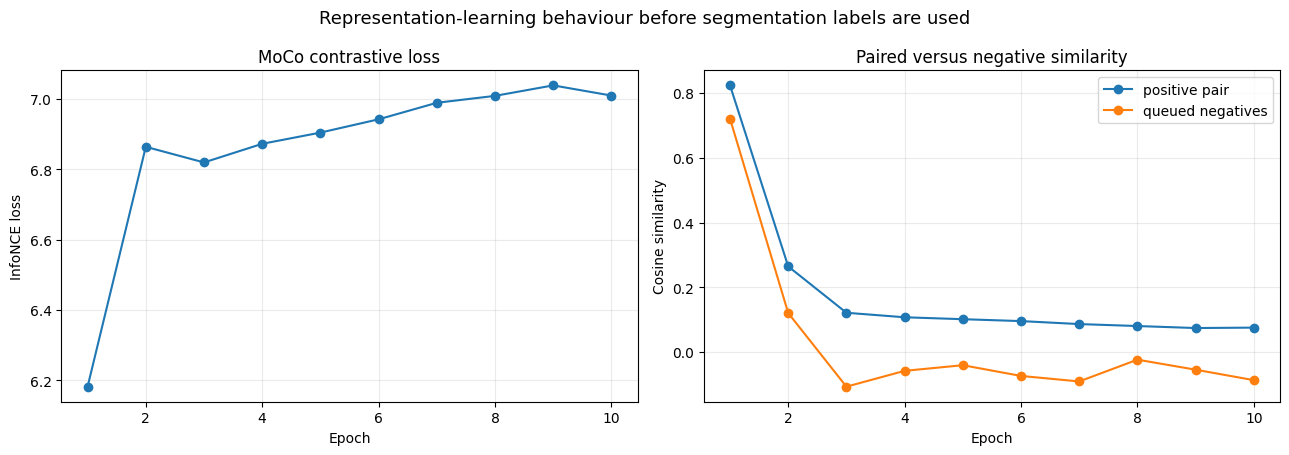

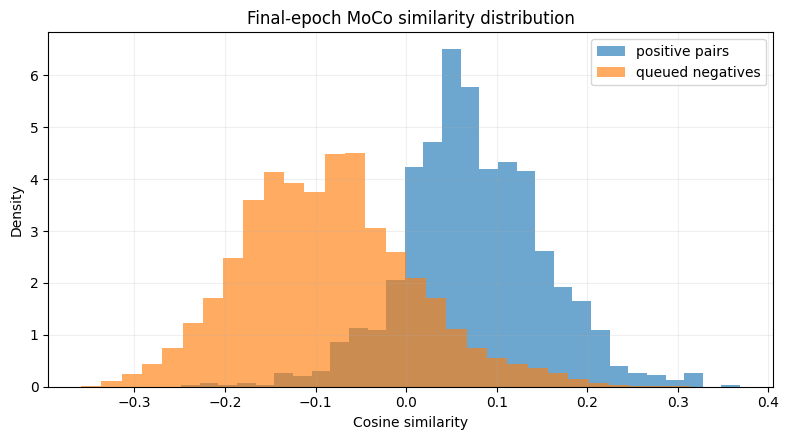

Interpretation: a useful contrastive representation should progressively assign higher similarity to two views of one MRI than to queued images.


In [9]:

# ============================================================
# 9. MoCo learning diagnostics: loss and similarity distributions
# ============================================================

figure, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].plot(moco_history_df["epoch"], moco_history_df["moco_loss"], marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("InfoNCE loss")
axes[0].set_title("MoCo contrastive loss")
axes[0].grid(alpha=0.25)

axes[1].plot(
    moco_history_df["epoch"], moco_history_df["positive_similarity"],
    marker="o", label="positive pair"
)
axes[1].plot(
    moco_history_df["epoch"], moco_history_df["negative_similarity"],
    marker="o", label="queued negatives"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Cosine similarity")
axes[1].set_title("Paired versus negative similarity")
axes[1].legend()
axes[1].grid(alpha=0.25)

figure.suptitle("Representation-learning behaviour before segmentation labels are used", fontsize=13)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "05_moco_training_curves.png", dpi=180, bbox_inches="tight")
plt.show()

figure, axis = plt.subplots(figsize=(8, 4.5))
axis.hist(final_positive_similarities, bins=30, density=True, alpha=0.65, label="positive pairs")
axis.hist(final_negative_similarities, bins=30, density=True, alpha=0.65, label="queued negatives")
axis.set_xlabel("Cosine similarity")
axis.set_ylabel("Density")
axis.set_title("Final-epoch MoCo similarity distribution")
axis.legend()
axis.grid(alpha=0.2)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "06_moco_similarity_histogram.png", dpi=180, bbox_inches="tight")
plt.show()

print(
    "Interpretation: a useful contrastive representation should progressively assign "
    "higher similarity to two views of one MRI than to queued images."
)



## DeepLabV3 fine-tuning

DeepLabV3 applies atrous spatial pyramid pooling to obtain multi-scale semantic context. Here its ResNet-50 feature extractor is not left at random initialisation: compatible convolutional and normalisation parameters are loaded from the trained MoCo query encoder. The final classifier predicts two pixel classes.


In [10]:

# ============================================================
# 10. Transfer the MoCo query encoder into DeepLabV3-ResNet50
# ============================================================

def build_deeplab_from_moco(trained_moco_model):
    """
    Construct DeepLabV3 with a two-class output layer and transfer every
    shape-compatible query-encoder parameter into its ResNet-50 backbone.
    No unrelated encoder architecture is used.
    """
    segmentation_model = deeplabv3_resnet50(
        weights=None,
        weights_backbone=None,
        num_classes=NUM_CLASSES,
        aux_loss=True,
    )

    query_state = trained_moco_model.encoder_q.state_dict()
    backbone_state = segmentation_model.backbone.state_dict()

    transferable = {
        key: value.detach().cpu()
        for key, value in query_state.items()
        if key in backbone_state and backbone_state[key].shape == value.shape
    }

    missing_keys, unexpected_keys = segmentation_model.backbone.load_state_dict(
        transferable, strict=False
    )

    print(f"Transferred encoder tensors: {len(transferable)}")
    print(f"Remaining DeepLabV3 backbone entries not loaded from MoCo: {len(missing_keys)}")
    print(f"Unexpected transferred entries: {len(unexpected_keys)}")
    return segmentation_model

segmentation_model = build_deeplab_from_moco(moco_model).to(DEVICE)

class CrossEntropyForegroundDiceLoss(nn.Module):
    """Combine multiclass cross-entropy with Dice loss on the tumour foreground."""
    def __init__(self, dice_weight=1.0, epsilon=1e-6):
        super().__init__()
        self.dice_weight = dice_weight
        self.epsilon = epsilon

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets)
        tumour_probability = torch.softmax(logits.float(), dim=1)[:, 1]
        tumour_target = (targets == 1).float()

        intersection = (tumour_probability * tumour_target).sum(dim=(1, 2))
        denominator = tumour_probability.sum(dim=(1, 2)) + tumour_target.sum(dim=(1, 2))
        dice = (2.0 * intersection + self.epsilon) / (denominator + self.epsilon)
        dice_loss = 1.0 - dice.mean()
        return ce_loss + self.dice_weight * dice_loss, ce_loss.detach(), dice_loss.detach()

criterion = CrossEntropyForegroundDiceLoss(dice_weight=1.0)
segmentation_optimizer = torch.optim.AdamW(
    segmentation_model.parameters(),
    lr=SEGMENTATION_LR,
    weight_decay=WEIGHT_DECAY,
)
segmentation_scaler = make_grad_scaler()

def segmentation_counts(prediction, target):
    """Return confusion-count components for tumour-class metrics."""
    prediction = prediction == 1
    target = target == 1
    true_positive = (prediction & target).sum().item()
    false_positive = (prediction & ~target).sum().item()
    false_negative = (~prediction & target).sum().item()
    correctly_classified = (prediction == target).sum().item()
    total_pixels = target.numel()
    return true_positive, false_positive, false_negative, correctly_classified, total_pixels

def metrics_from_counts(tp, fp, fn, correct, total, epsilon=1e-7):
    return {
        "dice": (2.0 * tp + epsilon) / (2.0 * tp + fp + fn + epsilon),
        "iou": (tp + epsilon) / (tp + fp + fn + epsilon),
        "pixel_accuracy": correct / max(total, 1),
    }

def run_segmentation_epoch(model, loader, optimizer=None, scaler=None, stage="train"):
    training = optimizer is not None
    model.train(training)

    losses = []
    tp = fp = fn = correct = total = 0

    progress = tqdm(loader, desc=stage, leave=False)
    for images, masks, _ in progress:
        images = images.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        masks = masks.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with autocast_context():
                output = model(images)
                logits = F.interpolate(
                    output["out"], size=masks.shape[-2:],
                    mode="bilinear", align_corners=False
                )
                main_loss, _, _ = criterion(logits, masks)

                # DeepLabV3's auxiliary head improves optimisation during training.
                if training and "aux" in output:
                    auxiliary_logits = F.interpolate(
                        output["aux"], size=masks.shape[-2:],
                        mode="bilinear", align_corners=False
                    )
                    auxiliary_loss, _, _ = criterion(auxiliary_logits, masks)
                    loss = main_loss + 0.4 * auxiliary_loss
                else:
                    loss = main_loss

            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        losses.append(float(loss.detach().cpu()))
        prediction = logits.argmax(dim=1)
        batch_tp, batch_fp, batch_fn, batch_correct, batch_total = segmentation_counts(
            prediction.detach(), masks.detach()
        )
        tp += batch_tp
        fp += batch_fp
        fn += batch_fn
        correct += batch_correct
        total += batch_total

        progress.set_postfix(loss=f"{np.mean(losses):.4f}")

    epoch_metrics = metrics_from_counts(tp, fp, fn, correct, total)
    epoch_metrics["loss"] = float(np.mean(losses))
    return epoch_metrics


Transferred encoder tensors: 318
Remaining DeepLabV3 backbone entries not loaded from MoCo: 0
Unexpected transferred entries: 0


In [11]:

# ============================================================
# 11. Ten-epoch DeepLabV3 semantic-segmentation fine-tuning
# ============================================================

segmentation_history = []
best_validation_dice = -1.0
best_checkpoint_path = CHECKPOINT_DIR / "best_moco_deeplabv3_binary_segmentation.pth"

for epoch in range(1, SEGMENTATION_EPOCHS + 1):
    train_metrics = run_segmentation_epoch(
        segmentation_model,
        train_loader,
        optimizer=segmentation_optimizer,
        scaler=segmentation_scaler,
        stage=f"Seg train {epoch:02d}/{SEGMENTATION_EPOCHS}",
    )
    validation_metrics = run_segmentation_epoch(
        segmentation_model,
        valid_loader,
        optimizer=None,
        scaler=None,
        stage=f"Seg valid {epoch:02d}/{SEGMENTATION_EPOCHS}",
    )

    record = {"epoch": epoch}
    for name, value in train_metrics.items():
        record[f"train_{name}"] = value
    for name, value in validation_metrics.items():
        record[f"valid_{name}"] = value
    segmentation_history.append(record)

    print(
        f"Epoch {epoch:02d}: "
        f"train loss={train_metrics['loss']:.4f}, train Dice={train_metrics['dice']:.4f} | "
        f"valid loss={validation_metrics['loss']:.4f}, valid Dice={validation_metrics['dice']:.4f}, "
        f"valid IoU={validation_metrics['iou']:.4f}"
    )

    if validation_metrics["dice"] > best_validation_dice:
        best_validation_dice = validation_metrics["dice"]
        torch.save(
            {
                "model_state_dict": segmentation_model.state_dict(),
                "epoch": epoch,
                "validation_metrics": validation_metrics,
                "source_encoder": "MoCo query encoder ResNet-50",
            },
            best_checkpoint_path,
        )

segmentation_history_df = pd.DataFrame(segmentation_history)
segmentation_history_df.to_csv(METRIC_DIR / "deeplabv3_training_history.csv", index=False)

# Evaluate only the best validation checkpoint on the held-out test split.
best_checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)
segmentation_model.load_state_dict(best_checkpoint["model_state_dict"])
test_metrics = run_segmentation_epoch(
    segmentation_model, test_loader, optimizer=None, scaler=None, stage="Test evaluation"
)

test_result_df = pd.DataFrame([test_metrics])
test_result_df.to_csv(METRIC_DIR / "test_metrics.csv", index=False)

print("\nHeld-out test performance from the best validation checkpoint")
print(test_result_df.round(4).to_string(index=False))
print(f"\nBest checkpoint: {best_checkpoint_path}")


Seg train 01/10:   0%|          | 0/251 [00:00<?, ?it/s]

Seg valid 01/10:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 01: train loss=1.1579, train Dice=0.4013 | valid loss=0.6053, valid Dice=0.5547, valid IoU=0.3838


Seg train 02/10:   0%|          | 0/251 [00:00<?, ?it/s]

Seg valid 02/10:   0%|          | 0/72 [00:00<?, ?it/s]

...

Seg train 10/10:   0%|          | 0/251 [00:00<?, ?it/s]

Seg valid 10/10:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 10: train loss=0.5011, train Dice=0.7260 | valid loss=0.3852, valid Dice=0.6987, valid IoU=0.5369


Test evaluation:   0%|          | 0/36 [00:00<?, ?it/s]


Held-out test performance from the best validation checkpoint
  dice    iou  pixel_accuracy   loss
0.6815 0.5168          0.9755 0.3981

Best checkpoint: /kaggle/working/moco_deeplabv3_brain_tumour/checkpoints/best_moco_deeplabv3_binary_segmentation.pth


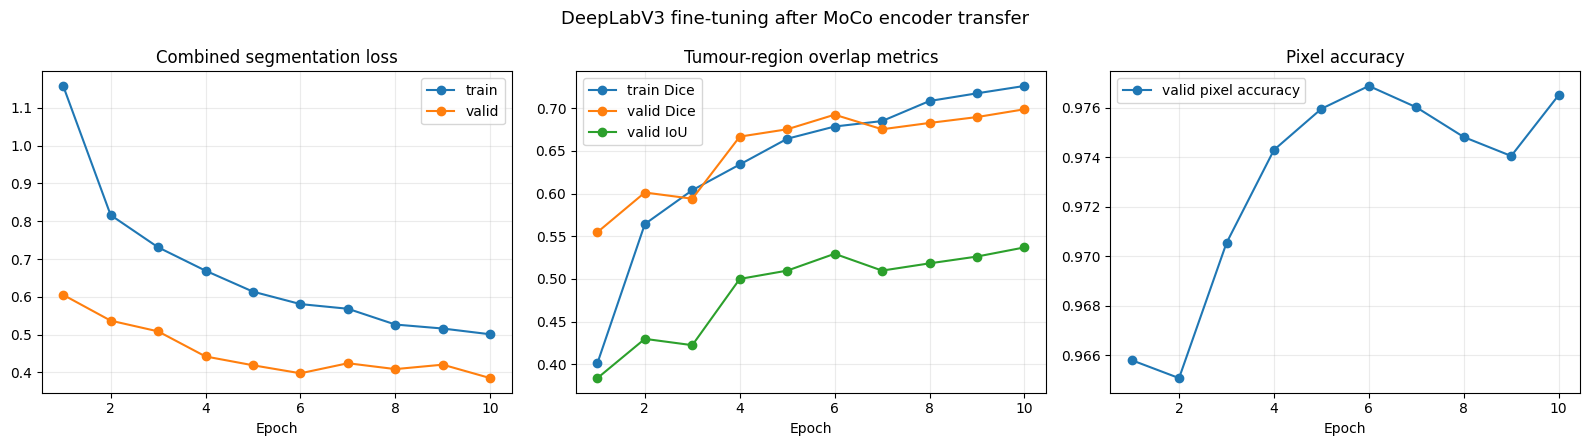

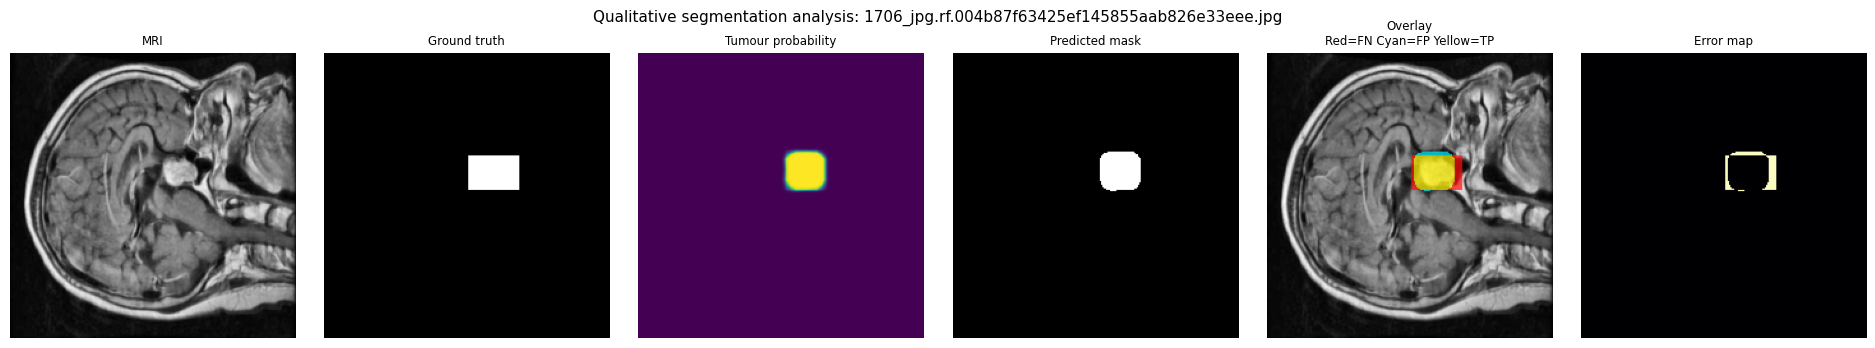

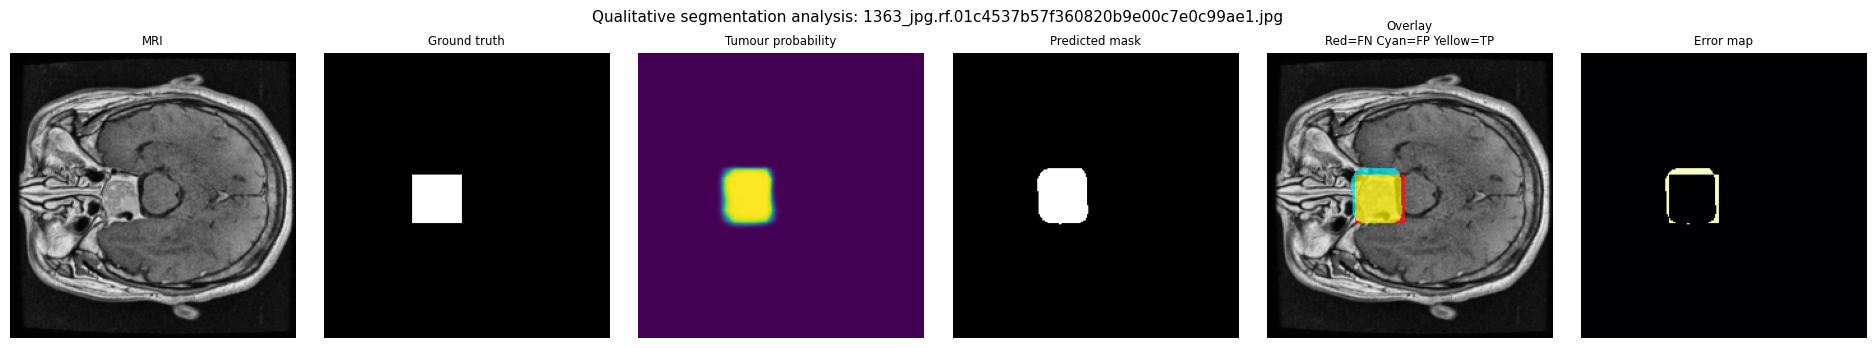

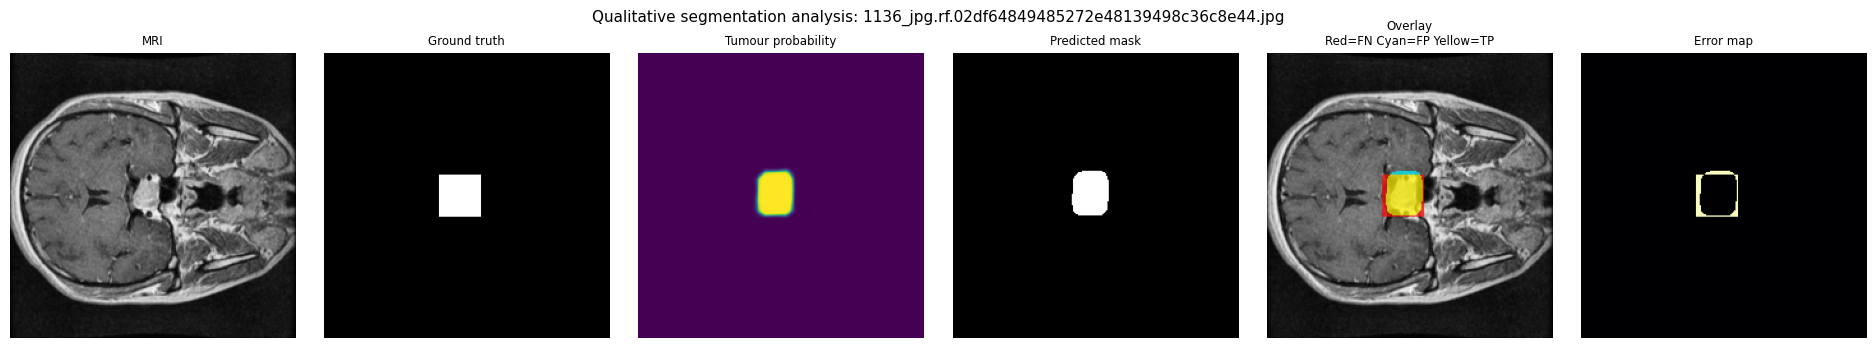

In [12]:

# ============================================================
# 12. Segmentation curves and test-set qualitative predictions
# ============================================================

figure, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(segmentation_history_df["epoch"], segmentation_history_df["train_loss"], marker="o", label="train")
axes[0].plot(segmentation_history_df["epoch"], segmentation_history_df["valid_loss"], marker="o", label="valid")
axes[0].set_title("Combined segmentation loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(segmentation_history_df["epoch"], segmentation_history_df["train_dice"], marker="o", label="train Dice")
axes[1].plot(segmentation_history_df["epoch"], segmentation_history_df["valid_dice"], marker="o", label="valid Dice")
axes[1].plot(segmentation_history_df["epoch"], segmentation_history_df["valid_iou"], marker="o", label="valid IoU")
axes[1].set_title("Tumour-region overlap metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.25)

axes[2].plot(
    segmentation_history_df["epoch"], segmentation_history_df["valid_pixel_accuracy"],
    marker="o", label="valid pixel accuracy"
)
axes[2].set_title("Pixel accuracy")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(alpha=0.25)

figure.suptitle("DeepLabV3 fine-tuning after MoCo encoder transfer", fontsize=13)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "07_segmentation_curves.png", dpi=180, bbox_inches="tight")
plt.show()

@torch.inference_mode()
def predict_one_sample(model, dataset, index):
    image, ground_truth, file_name = dataset[index]
    input_tensor = image.unsqueeze(0).to(DEVICE).contiguous()

    with autocast_context():
        output = model(input_tensor)["out"]
        logits = F.interpolate(
            output, size=ground_truth.shape[-2:],
            mode="bilinear", align_corners=False
        )
        probability = torch.softmax(logits.float(), dim=1)[0, 1].cpu()

    predicted_mask = (probability >= 0.5).long()
    return image, ground_truth, probability, predicted_mask, file_name

def make_comparison_overlay(image_array, ground_truth_array, predicted_array, alpha=0.72):
    """
    Colour-code the segmentation result on the MRI:
      red    = missed ground-truth tumour area (false negative),
      cyan   = predicted-only area (false positive),
      yellow = overlapping prediction and ground truth (true positive).

    When the prediction is empty, the ground-truth tumour remains visible in red.
    """
    overlay = image_array.copy()
    ground_truth_region = np.asarray(ground_truth_array).astype(bool)
    predicted_region = np.asarray(predicted_array).astype(bool)

    true_positive = ground_truth_region & predicted_region
    false_negative = ground_truth_region & ~predicted_region
    false_positive = predicted_region & ~ground_truth_region

    colour_regions = [
        (false_negative, np.array([1.0, 0.05, 0.05], dtype=np.float32)),
        (false_positive, np.array([0.0, 0.95, 1.0], dtype=np.float32)),
        (true_positive, np.array([1.0, 0.95, 0.0], dtype=np.float32)),
    ]

    for region, colour in colour_regions:
        if region.any():
            overlay[region] = (1.0 - alpha) * overlay[region] + alpha * colour

    return np.clip(overlay, 0.0, 1.0)

# Prefer test samples containing foreground pixels for meaningful interpretation.
candidate_indices = [
    i for i in range(len(test_dataset)) if test_dataset[i][1].sum().item() > 0
][:3]
if len(candidate_indices) == 0:
    candidate_indices = list(range(min(3, len(test_dataset))))

for row, sample_index in enumerate(candidate_indices):
    image, ground_truth, probability, predicted_mask, file_name = predict_one_sample(
        segmentation_model, test_dataset, sample_index
    )

    image_array = undo_normalisation(image)
    ground_truth_array = ground_truth.numpy()
    probability_array = probability.numpy()
    predicted_array = predicted_mask.numpy()
    error_array = (predicted_mask != ground_truth).numpy().astype(np.float32)
    comparison_overlay = make_comparison_overlay(
        image_array, ground_truth_array, predicted_array
    )

    figure, axes = plt.subplots(1, 6, figsize=(19, 3.5))
    panels = [
        (image_array, "MRI", None),
        (ground_truth_array, "Ground truth", "gray"),
        (probability_array, "Tumour probability", "viridis"),
        (predicted_array, "Predicted mask", "gray"),
        (comparison_overlay, "Overlay\nRed=FN Cyan=FP Yellow=TP", None),
        (error_array, "Error map", "magma"),
    ]

    for axis, (content, title, colour_map) in zip(axes, panels):
        axis.imshow(content, cmap=colour_map, vmin=0 if colour_map else None, vmax=1 if colour_map else None)
        axis.set_title(title, fontsize=8.5)
        axis.axis("off")

    figure.suptitle(f"Qualitative segmentation analysis: {file_name}", fontsize=11)
    figure.tight_layout()
    figure.savefig(FIGURE_DIR / f"08_prediction_example_{row + 1}.png", dpi=180, bbox_inches="tight")
    plt.show()



## Feature-space study

A t-SNE plot is provided at three stages:

1. **Initial encoder:** features before any MoCo update.
2. **After MoCo:** features learned from paired views and the negative queue.
3. **After DeepLabV3 fine-tuning:** features after direct supervision from tumour masks.

The colour label indicates whether an MRI contains at least one tumour pixel. t-SNE is a local-neighbourhood visualisation; distances between separate panels should not be interpreted as an absolute metric of representation quality.


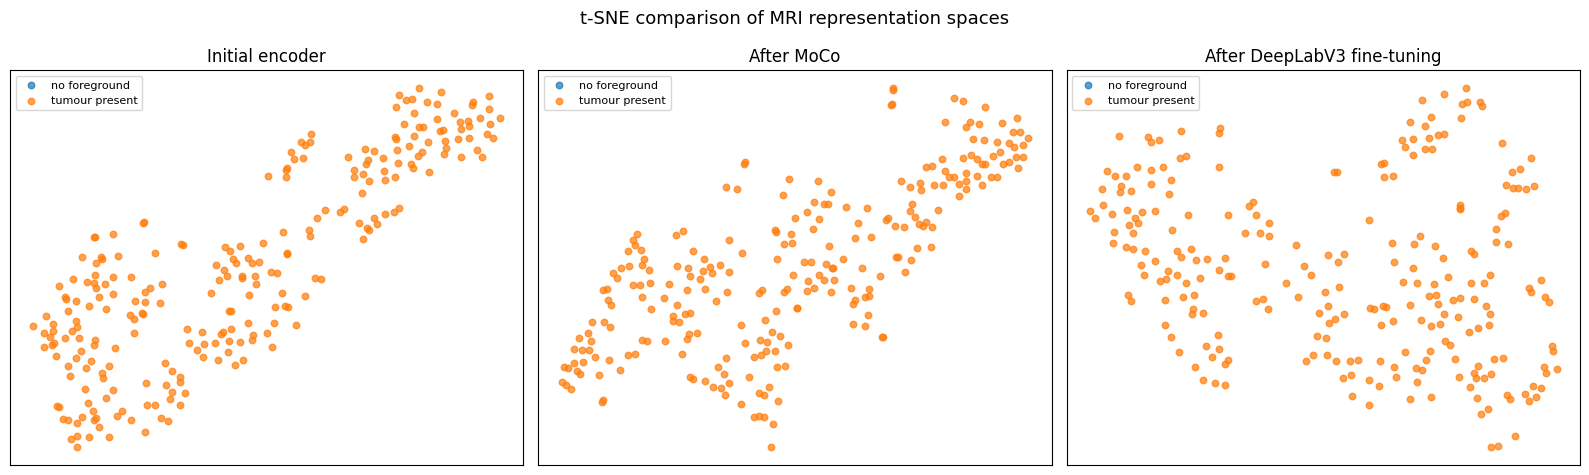

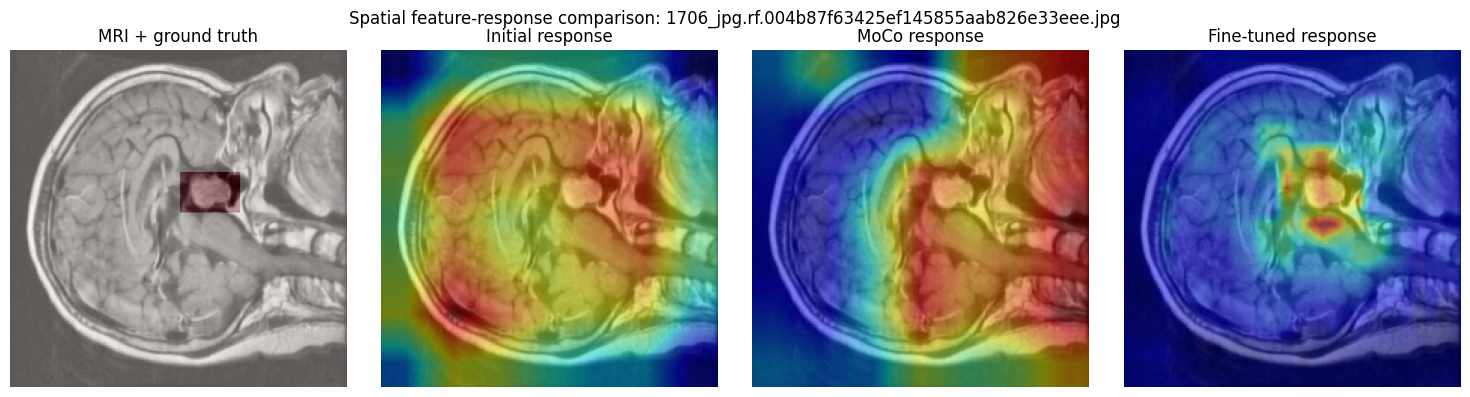

In [13]:

# ============================================================
# 13. Spatial feature responses and t-SNE at three learning stages
# ============================================================

def resnet_spatial_features(encoder, images):
    """Return the final convolutional feature grid before global average pooling."""
    x = encoder.conv1(images)
    x = encoder.bn1(x)
    x = encoder.relu(x)
    x = encoder.maxpool(x)
    x = encoder.layer1(x)
    x = encoder.layer2(x)
    x = encoder.layer3(x)
    return encoder.layer4(x)

# Recover the untrained query encoder and retain the trained MoCo query encoder.
initial_encoder = build_resnet_encoder(use_imagenet=False).to(DEVICE)
initial_encoder.load_state_dict(initial_encoder_state)
initial_encoder.eval()

moco_encoder = copy.deepcopy(moco_model.encoder_q).to(DEVICE)
moco_encoder.eval()
segmentation_model.eval()

@torch.inference_mode()
def collect_encoder_features(encoder, loader, maximum_samples=250):
    features, labels = [], []
    for images, masks, _ in loader:
        images = images.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        vectors = encoder(images).float().cpu().numpy()
        tumour_present = (masks.flatten(1).sum(dim=1) > 0).long().numpy()
        features.append(vectors)
        labels.append(tumour_present)
        if sum(len(part) for part in labels) >= maximum_samples:
            break
    return np.concatenate(features)[:maximum_samples], np.concatenate(labels)[:maximum_samples]

@torch.inference_mode()
def collect_deeplab_features(model, loader, maximum_samples=250):
    features, labels = [], []
    for images, masks, _ in loader:
        images = images.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        feature_grid = model.backbone(images)["out"]
        vectors = F.adaptive_avg_pool2d(feature_grid.float(), output_size=1).flatten(1).cpu().numpy()
        tumour_present = (masks.flatten(1).sum(dim=1) > 0).long().numpy()
        features.append(vectors)
        labels.append(tumour_present)
        if sum(len(part) for part in labels) >= maximum_samples:
            break
    return np.concatenate(features)[:maximum_samples], np.concatenate(labels)[:maximum_samples]

initial_features, feature_labels = collect_encoder_features(initial_encoder, feature_loader)
moco_features, _ = collect_encoder_features(moco_encoder, feature_loader)
finetuned_features, _ = collect_deeplab_features(segmentation_model, feature_loader)

def compute_tsne(features):
    scaled_features = StandardScaler().fit_transform(features)
    sample_count = scaled_features.shape[0]
    perplexity = max(2, min(30, sample_count // 4, sample_count - 1))
    return TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=SEED,
    ).fit_transform(scaled_features)

embeddings = [
    compute_tsne(initial_features),
    compute_tsne(moco_features),
    compute_tsne(finetuned_features),
]
titles = ["Initial encoder", "After MoCo", "After DeepLabV3 fine-tuning"]

figure, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for axis, embedded, title in zip(axes, embeddings, titles):
    for class_value, label_name in [(0, "no foreground"), (1, "tumour present")]:
        selected = feature_labels == class_value
        axis.scatter(embedded[selected, 0], embedded[selected, 1], s=22, alpha=0.72, label=label_name)
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.legend(fontsize=8)

figure.suptitle("t-SNE comparison of MRI representation spaces", fontsize=13)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "09_tsne_three_stages.png", dpi=180, bbox_inches="tight")
plt.show()

# ----- Spatial response maps for one foreground-positive MRI.
visual_index = candidate_indices[0] if len(candidate_indices) > 0 else 0
visual_image, visual_mask, visual_name = test_dataset[visual_index]
visual_batch = visual_image.unsqueeze(0).to(DEVICE).contiguous()

@torch.inference_mode()
def normalised_response_map(feature_grid, output_size):
    response = feature_grid.float().abs().mean(dim=1, keepdim=True)
    response = F.interpolate(response, size=output_size, mode="bilinear", align_corners=False)[0, 0]
    response = response - response.min()
    response = response / (response.max() + 1e-7)
    return response.cpu().numpy()

with torch.inference_mode():
    initial_map = normalised_response_map(
        resnet_spatial_features(initial_encoder, visual_batch), visual_mask.shape[-2:]
    )
    moco_map = normalised_response_map(
        resnet_spatial_features(moco_encoder, visual_batch), visual_mask.shape[-2:]
    )
    finetuned_map = normalised_response_map(
        segmentation_model.backbone(visual_batch)["out"], visual_mask.shape[-2:]
    )

base_image = undo_normalisation(visual_image)
figure, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(base_image)
axes[0].imshow(visual_mask.numpy(), cmap="Reds", alpha=0.35)
axes[0].set_title("MRI + ground truth")
for axis, response, title in zip(
    axes[1:],
    [initial_map, moco_map, finetuned_map],
    ["Initial response", "MoCo response", "Fine-tuned response"],
):
    axis.imshow(base_image)
    axis.imshow(response, cmap="jet", alpha=0.48, vmin=0, vmax=1)
    axis.set_title(title)
for axis in axes:
    axis.axis("off")

figure.suptitle(f"Spatial feature-response comparison: {visual_name}", fontsize=12)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "10_spatial_response_three_stages.png", dpi=180, bbox_inches="tight")
plt.show()


In [14]:

# ============================================================
# 14. Export experiment summary for reporting
# ============================================================

summary = {
    "course": "CSE 438: Digital Image Processing",
    "instructor": "Dr Md Rifat Ahmmad Rashid",
    "method": "MoCo query ResNet-50 encoder transferred to DeepLabV3-ResNet50",
    "dataset_root": str(DATA_ROOT),
    "mask_classes": {"0": "background", "1": "tumour region"},
    "device": str(DEVICE),
    "amp_enabled": bool(AMP_ENABLED),
    "moco_epochs": MOCO_EPOCHS,
    "segmentation_epochs": SEGMENTATION_EPOCHS,
    "moco_configuration": {
        "queue_size": QUEUE_SIZE,
        "momentum": MOMENTUM,
        "temperature": TEMPERATURE,
        "embedding_dim": EMBEDDING_DIM,
    },
    "best_validation_dice": float(best_validation_dice),
    "test_metrics": {key: float(value) for key, value in test_metrics.items()},
    "saved_outputs": {
        "figures": str(FIGURE_DIR),
        "checkpoints": str(CHECKPOINT_DIR),
        "metrics": str(METRIC_DIR),
    },
}

with open(OUTPUT_DIR / "experiment_summary.json", "w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2)

print(json.dumps(summary, indent=2))
print("\nSummary comment:")
print(
    "MoCo pretraining establishes an unlabelled representation-learning stage; "
    "DeepLabV3 then uses the directly transferred query encoder to learn binary tumour boundaries. "
    "Interpret Dice and IoU together with qualitative error maps, t-SNE neighbourhoods, "
    "and spatial response changes rather than relying only on pixel accuracy."
)


{
  "course": "CSE 438: Digital Image Processing",
  "instructor": "Dr Md Rifat Ahmmad Rashid",
  "method": "MoCo query ResNet-50 encoder transferred to DeepLabV3-ResNet50",
  "dataset_root": "/kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation",
  "mask_classes": {
    "0": "background",
    "1": "tumour region"
  },
  "device": "cuda",
  "amp_enabled": true,
  "moco_epochs": 10,
  "segmentation_epochs": 10,
  "moco_configuration": {
    "queue_size": 2048,
    "momentum": 0.999,
    "temperature": 0.2,
    "embedding_dim": 128
  },
  "best_validation_dice": 0.6986548543727092,
  "test_metrics": {
    "dice": 0.6814652530799942,
    "iou": 0.5168352632889669,
    "pixel_accuracy": 0.9755246648077835,
    "loss": 0.3980531307558219
  },
  "saved_outputs": {
    "figures": "/kaggle/working/moco_deeplabv3_brain_tumour/figures",
    "checkpoints": "/kaggle/working/moco_deeplabv3_brain_tumour/checkpoints",
    "metrics": "/kaggle/working/moco_deeplabv3_brain_tum


## References

1. He, K., Fan, H., Wu, Y., Xie, S., and Girshick, R. (2020). *Momentum Contrast for Unsupervised Visual Representation Learning*. Proceedings of CVPR, 9729–9738.  
2. Chen, X., Fan, H., Girshick, R., and He, K. (2020). *Improved Baselines with Momentum Contrastive Learning*. arXiv:2003.04297.  
3. Chen, L.-C., Papandreou, G., Schroff, F., and Adam, H. (2017). *Rethinking Atrous Convolution for Semantic Image Segmentation*. arXiv:1706.05587.

### Classroom interpretation

The final comparison should address three questions. First, did the MoCo loss and similarity distributions indicate successful instance-discrimination learning? Second, did the transferred backbone support accurate foreground overlap, particularly under the class imbalance evident in the mask distribution? Third, did the feature-space and response-map plots reveal a visible transition from generic image structure towards tumour-relevant spatial evidence?
